In [1]:
!pip install pyomo
!pip install gurobipy

from pyomo.environ import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 80.4 MB/s eta 0:00:00


In [2]:
hospitals_data = pd.DataFrame({
    'hospital_id': ['H1', 'H2', 'H3', 'H4', 'H5', 'H6'],
    'trauma_level': ['I', 'II', 'II', 'III', 'III', 'III'],
    'criticality_weight': [3, 2, 2, 1, 1, 1],
    'base_daily_demand': [15, 8, 8, 3, 3, 3]
})
hospitals_data.to_csv('hospitals.csv', index=False)

scenarios_data = pd.DataFrame({
    'scenario_id': ['S1', 'S2', 'S3'],
    'scenario_name': ['Normal Day', 'Elevated Activity', 'Mass Casualty Event'],
    'demand_factor': [1.0, 1.5, 4.5],
    'probability': [0.85, 0.10, 0.05]
})
scenarios_data.to_csv('scenarios.csv', index=False)

print(hospitals_data)
print(scenarios_data)

  hospital_id trauma_level  criticality_weight  base_daily_demand
0          H1            I                   3                 15
1          H2           II                   2                  8
2          H3           II                   2                  8
3          H4          III                   1                  3
4          H5          III                   1                  3
5          H6          III                   1                  3
  scenario_id        scenario_name  demand_factor  probability
0          S1           Normal Day            1.0         0.85
1          S2    Elevated Activity            1.5         0.10
2          S3  Mass Casualty Event            4.5         0.05


In [3]:
def build_model(hospitals_df, scenarios_df, total_supply):
    model = ConcreteModel()

    model.H = Set(initialize=hospitals_df['hospital_id'].tolist())
    model.S = Set(initialize=scenarios_df['scenario_id'].tolist())

    w_dict = dict(zip(hospitals_df['hospital_id'], hospitals_df['criticality_weight']))
    D_base_dict = dict(zip(hospitals_df['hospital_id'], hospitals_df['base_daily_demand']))
    factor_dict = dict(zip(scenarios_df['scenario_id'], scenarios_df['demand_factor']))
    p_dict = dict(zip(scenarios_df['scenario_id'], scenarios_df['probability']))

    model.w = Param(model.H, initialize=w_dict)
    model.D_base = Param(model.H, initialize=D_base_dict)
    model.factor = Param(model.S, initialize=factor_dict)
    model.p = Param(model.S, initialize=p_dict)
    model.I = Param(initialize=total_supply)

    def D_rule(model, h, s):
        return model.D_base[h] * model.factor[s]
    model.D = Param(model.H, model.S, initialize=D_rule)

    return model

In [4]:
def add_optimization_components(model):
    model.x = Var(model.H, domain=NonNegativeReals)
    model.u = Var(model.H, model.S, domain=NonNegativeReals)

    def obj_rule(model):
        return sum(model.p[s] * model.w[h] * model.u[h, s]
                   for h in model.H for s in model.S)
    model.obj = Objective(rule=obj_rule, sense=minimize)

    def supply_rule(model):
        return sum(model.x[h] for h in model.H) <= model.I
    model.supply_constraint = Constraint(rule=supply_rule)

    def shortage_rule(model, h, s):
        return model.u[h, s] >= model.D[h, s] - model.x[h]
    model.shortage_constraint = Constraint(model.H, model.S, rule=shortage_rule)

    return model

In [5]:
hospitals_df = pd.read_csv('hospitals.csv')
scenarios_df = pd.read_csv('scenarios.csv')

model = build_model(hospitals_df, scenarios_df, total_supply=28)
model = add_optimization_components(model)

solver = SolverFactory('gurobi', solver_io='python')
result = solver.solve(model, tee=True)

print("\nSolver status:", result.solver.termination_condition)
print("Objective value (expected weighted shortage):", round(model.obj(), 3))

allocation_results = pd.DataFrame({
    'hospital_id': list(model.H),
    'allocated_blood': [round(model.x[h](), 2) for h in model.H]
})
print("\nAllocation per hospital:")
print(allocation_results)

shortage_results = pd.DataFrame({
    (h, s): model.u[h, s]() for h in model.H for s in model.S
}.items(), columns=['hospital_scenario', 'shortage'])
print("\nShortage per hospital/scenario:")
print(shortage_results)

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 19 rows, 24 columns and 42 nonzeros (Min)
Model fingerprint: 0xf670af89
Model has 18 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-02, 3e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 7e+01]

Presolve removed 3 rows and 3 columns
Presolve time: 0.01s
Presolved: 16 rows, 21 columns, 36 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.3125000e+01   5.150000e+01   0.000000e+00      0s
      17    3.4350000e+01   0.000000e+00   0.000000e+00      0s

Solved in 17 iterations and 0.01 seconds (0.00 work units)
Optimal objective  3.435000000e+01

Solver status: optimal
Objective value (expected weighted shortage): 34.35


In [6]:
def build_and_solve_equity_model(hospitals_df, scenarios_df, total_supply, min_fraction=0.5):
    model2 = build_model(hospitals_df, scenarios_df, total_supply)
    model2 = add_optimization_components(model2)

    def equity_rule(model, h):
        return model.x[h] >= min_fraction * model.D_base[h]
    model2.equity_constraint = Constraint(model2.H, rule=equity_rule)

    solver = SolverFactory('gurobi', solver_io='python')
    result = solver.solve(model2, tee=False)

    model2.solver_status = str(result.solver.termination_condition)

    return model2

model_equity = build_and_solve_equity_model(hospitals_df, scenarios_df, total_supply=28, min_fraction=0.5)

print("Objective value (with 50% equity floor):", round(model_equity.obj(), 3))
allocation_equity = pd.DataFrame({
    'hospital_id': list(model_equity.H),
    'allocated_blood_equity': [round(model_equity.x[h](), 2) for h in model_equity.H]
})
print(allocation_equity)

Objective value (with 50% equity floor): 38.85
  hospital_id  allocated_blood_equity
0          H1                    15.0
1          H2                     4.0
2          H3                     4.5
3          H4                     1.5
4          H5                     1.5
5          H6                     1.5


In [7]:
pareto_results = []

for frac in np.arange(0, 1.0, 0.1):
    m = build_and_solve_equity_model(hospitals_df, scenarios_df, total_supply=28, min_fraction=round(frac, 2))
    if m.solver_status == 'optimal':
        pareto_results.append({
            'min_fraction': round(frac, 2),
            'objective_value': round(m.obj(), 3),
            'feasible': True
        })
    else:
        pareto_results.append({
            'min_fraction': round(frac, 2),
            'objective_value': None,
            'feasible': False
        })

pareto_df = pd.DataFrame(pareto_results)
print(pareto_df)

  - termination condition: infeasible
  - message from solver: <undefined>
  - termination condition: infeasible
  - message from solver: <undefined>


   min_fraction  objective_value  feasible
0           0.0            34.35      True
1           0.1            35.25      True
2           0.2            36.15      True
3           0.3            37.05      True
4           0.4            37.95      True
5           0.5            38.85      True
6           0.6            41.75      True
7           0.7            45.15      True
8           0.8              NaN     False
9           0.9              NaN     False


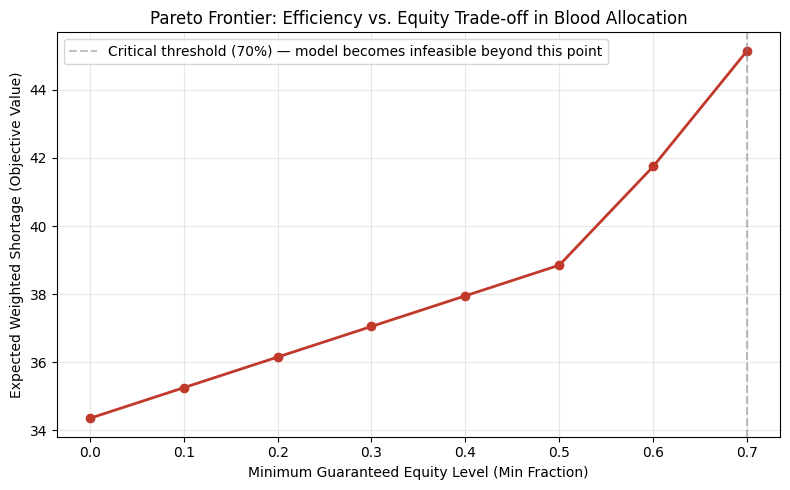

In [8]:
feasible_df = pareto_df[pareto_df['feasible'] == True]

plt.figure(figsize=(8, 5))
plt.plot(feasible_df['min_fraction'], feasible_df['objective_value'],
         marker='o', linewidth=2, color='#c0392b')
plt.xlabel('Minimum Guaranteed Equity Level (Min Fraction)')
plt.ylabel('Expected Weighted Shortage (Objective Value)')
plt.title('Pareto Frontier: Efficiency vs. Equity Trade-off in Blood Allocation')
plt.grid(True, alpha=0.3)
plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5,
            label='Critical threshold (70%) — model becomes infeasible beyond this point')
plt.legend()
plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=150)
plt.show()

In [9]:
def compute_expected_value_solution(hospitals_df, scenarios_df, total_supply):
    expected_demand = {}
    for h in hospitals_df['hospital_id']:
        base = hospitals_df.loc[hospitals_df['hospital_id'] == h, 'base_daily_demand'].values[0]
        exp_val = sum(
            scenarios_df.loc[scenarios_df['scenario_id'] == s, 'probability'].values[0] *
            base * scenarios_df.loc[scenarios_df['scenario_id'] == s, 'demand_factor'].values[0]
            for s in scenarios_df['scenario_id']
        )
        expected_demand[h] = exp_val

    total_expected_demand = sum(expected_demand.values())
    ev_allocation = {
        h: total_supply * (expected_demand[h] / total_expected_demand)
        for h in expected_demand
    }

    w_dict = dict(zip(hospitals_df['hospital_id'], hospitals_df['criticality_weight']))
    p_dict = dict(zip(scenarios_df['scenario_id'], scenarios_df['probability']))
    factor_dict = dict(zip(scenarios_df['scenario_id'], scenarios_df['demand_factor']))
    base_dict = dict(zip(hospitals_df['hospital_id'], hospitals_df['base_daily_demand']))

    ev_expected_cost = 0
    for h in expected_demand:
        for s in scenarios_df['scenario_id']:
            actual_demand = base_dict[h] * factor_dict[s]
            shortage = max(0, actual_demand - ev_allocation[h])
            ev_expected_cost += p_dict[s] * w_dict[h] * shortage

    return ev_allocation, ev_expected_cost

ev_allocation, ev_cost = compute_expected_value_solution(hospitals_df, scenarios_df, total_supply=28)

print("EV-based allocation (naive, based on average demand only):")
for h, val in ev_allocation.items():
    print(f"  {h}: {round(val, 2)}")
print(f"\nExpected cost under EV allocation (evaluated on real scenarios): {round(ev_cost, 3)}")
print(f"Expected cost under Stochastic Programming solution: {round(model.obj(), 3)}")

VSS = ev_cost - model.obj()
print(f"\nVSS (Value of Stochastic Solution) = {round(VSS, 3)}")


EV-based allocation (naive, based on average demand only):
  H1: 10.5
  H2: 5.6
  H3: 5.6
  H4: 2.1
  H5: 2.1
  H6: 2.1

Expected cost under EV allocation (evaluated on real scenarios): 45.15
Expected cost under Stochastic Programming solution: 34.35

VSS (Value of Stochastic Solution) = 10.8


In [10]:
def compute_perfect_information_value(hospitals_df, scenarios_df, total_supply):
    p_dict = dict(zip(scenarios_df['scenario_id'], scenarios_df['probability']))
    weighted_perfect_cost = 0

    for s in scenarios_df['scenario_id']:
        single_scenario_df = scenarios_df[scenarios_df['scenario_id'] == s].copy()
        single_scenario_df['probability'] = 1.0

        m_s = build_model(hospitals_df, single_scenario_df, total_supply)
        m_s = add_optimization_components(m_s)
        solver = SolverFactory('gurobi', solver_io='python')
        solver.solve(m_s, tee=False)

        weighted_perfect_cost += p_dict[s] * m_s.obj()

    return weighted_perfect_cost

perfect_info_cost = compute_perfect_information_value(hospitals_df, scenarios_df, total_supply=28)

print(f"Expected cost under Perfect Information: {round(perfect_info_cost, 3)}")
print(f"Expected cost under Stochastic Programming solution: {round(model.obj(), 3)}")

EVPI = model.obj() - perfect_info_cost
print(f"\nEVPI (Expected Value of Perfect Information) = {round(EVPI, 3)}")


Expected cost under Perfect Information: 32.95
Expected cost under Stochastic Programming solution: 34.35

EVPI (Expected Value of Perfect Information) = 1.4


In [11]:
dashboard_data = []

for frac in np.arange(0, 0.75, 0.05):
    m = build_and_solve_equity_model(hospitals_df, scenarios_df, total_supply=28, min_fraction=round(frac, 2))
    if m.solver_status == 'optimal':
        allocation = {h: round(m.x[h](), 2) for h in m.H}
        dashboard_data.append({
            'min_fraction': round(frac, 2),
            'objective_value': round(m.obj(), 3),
            'allocation': allocation,
            'feasible': True
        })
    else:
        dashboard_data.append({
            'min_fraction': round(frac, 2),
            'feasible': False
        })

dashboard_export = {
    'hospitals': hospitals_df.to_dict('records'),
    'sweep_data': dashboard_data,
    'vss': round(VSS, 3),
    'evpi': round(EVPI, 3),
    'stochastic_objective': round(model.obj(), 3),
    'ev_based_objective': round(ev_cost, 3),
    'perfect_info_objective': round(perfect_info_cost, 3)
}

with open('dashboard_data.json', 'w') as f:
    json.dump(dashboard_export, f, indent=2)

print(json.dumps(dashboard_export, indent=2))

{
  "hospitals": [
    {
      "hospital_id": "H1",
      "trauma_level": "I",
      "criticality_weight": 3,
      "base_daily_demand": 15
    },
    {
      "hospital_id": "H2",
      "trauma_level": "II",
      "criticality_weight": 2,
      "base_daily_demand": 8
    },
    {
      "hospital_id": "H3",
      "trauma_level": "II",
      "criticality_weight": 2,
      "base_daily_demand": 8
    },
    {
      "hospital_id": "H4",
      "trauma_level": "III",
      "criticality_weight": 1,
      "base_daily_demand": 3
    },
    {
      "hospital_id": "H5",
      "trauma_level": "III",
      "criticality_weight": 1,
      "base_daily_demand": 3
    },
    {
      "hospital_id": "H6",
      "trauma_level": "III",
      "criticality_weight": 1,
      "base_daily_demand": 3
    }
  ],
  "sweep_data": [
    {
      "min_fraction": 0.0,
      "objective_value": 34.35,
      "allocation": {
        "H1": 15.0,
        "H2": 5.0,
        "H3": 8.0,
        "H4": 0.0,
        "H5": 0.0,
     